# 准备环境

In [8]:
# # **************** UNCOMMENT AND RUN THIS CELL IF YOU NEED TO INSTALL/ UPGRADE TSAI ****************
# stable = True # Set to True for latest pip version or False for main branch in GitHub
# !pip install {"tsai -U" if stable else "git+https://github.com/timeseriesAI/tsai.git"} >> /dev/null

In [9]:
import sklearn
import pandas as pd
import numpy as np
from scipy import stats
from tsai.all import *
my_setup(sklearn)

os              : Linux-6.18.5-2-cachyos-x86_64-with-glibc2.42
python          : 3.12.11
tsai            : 0.4.1
fastai          : 2.8.6
fastcore        : 1.11.2
sklearn         : 1.7.1
torch           : 2.9.1+rocm6.4
device          : 1 gpu (['AMD Radeon Graphics'])
cpu cores       : 6
threads per cpu : 2
RAM             : 31.26 GB
GPU memory      : N/A


# 加载并处理数据

筛选相关站点

In [10]:
# ========== 1. 筛选相关站点 ==========
primary_var = "PM25_Concentration"
station_id_list = np.arange(9017, 9047).tolist() + [9058]
station_id_list = np.array(station_id_list)

r_thred = 0.85
center_station_id = 9022
station_id_related_list = []

df_one_station = pd.read_csv('tsai/data/stations_data_Guangzhou/df_station_{}.csv'.format(center_station_id))
v_list_1 = list(df_one_station[primary_var])

for station_id_other in station_id_list:
    df_one_station_other = pd.read_csv('tsai/data/stations_data_Guangzhou/df_station_{}.csv'.format(station_id_other))
    v_list_2 = list(df_one_station_other[primary_var])
    r, p = stats.pearsonr(v_list_1, v_list_2)
    if r > r_thred:
        station_id_related_list.append(station_id_other)

station_id_related_list = np.array(station_id_related_list)
# station_id_related_list = [9021, 9022, 9023]
print(f"相关站点数量: {len(station_id_related_list)}")
print(f"相关站点ID: {station_id_related_list}")

相关站点数量: 12
相关站点ID: [9017 9018 9019 9020 9022 9023 9027 9028 9033 9035 9038 9044]


========= 2. 合并多站点数据 ==========

In [11]:
# ========== 2. 正确合并多站点数据 ==========
dfs_to_merge = []

# 读取第一个站点获取原始特征列名
df_first_station = pd.read_csv(
    'tsai/data/stations_data_Guangzhou/df_station_{}.csv'.format(station_id_related_list[0])
)
original_feature_cols = [col for col in df_first_station.columns
                        if col not in ['station_id', 'time']]

print(f"每个站点的特征数: {len(original_feature_cols)}")
print(f"特征列: {original_feature_cols}")

# 为每个站点加载数据并重命名特征列
for station_id in station_id_related_list:
    df_one_station = pd.read_csv(
        f'tsai/data/stations_data_Guangzhou/df_station_{station_id}.csv'
    )

    # 转换时间列
    df_one_station["time"] = pd.to_datetime(df_one_station["time"])

    # 为特征列添加站点ID后缀,例如: PM25_Concentration -> PM25_Concentration_9022
    new_cols = {col: f"{col}_{station_id}" for col in original_feature_cols}

    # 选择并重命名列
    df_one_station_processed = df_one_station[['time'] + original_feature_cols].rename(columns=new_cols)

    dfs_to_merge.append(df_one_station_processed)

# 按时间合并所有站点数据 (使用outer join确保所有时间戳都保留)
df_raw = dfs_to_merge[0]
for i in range(1, len(dfs_to_merge)):
    df_raw = pd.merge(df_raw, dfs_to_merge[i], on='time', how='outer')

# 按时间排序并重置索引
df_raw = df_raw.sort_values("time").reset_index(drop=True)

print(f"\n合并后的数据形状: {df_raw.shape}")
print(f"合并后的列数: {len(df_raw.columns)}")
print(f"\n前5行数据:")
print(df_raw.head())

每个站点的特征数: 12
特征列: ['PM25_Concentration', 'PM10_Concentration', 'NO2_Concentration', 'CO_Concentration', 'O3_Concentration', 'SO2_Concentration', 'weather', 'temperature', 'pressure', 'humidity', 'wind_speed', 'wind_direction']

合并后的数据形状: (8760, 145)
合并后的列数: 145

前5行数据:
                 time  PM25_Concentration_9017  PM10_Concentration_9017  \
0 2014-05-01 00:00:00                     38.0                     44.0   
1 2014-05-01 01:00:00                     37.0                     48.0   
2 2014-05-01 02:00:00                     44.0                     54.0   
3 2014-05-01 03:00:00                     39.0                     51.0   
4 2014-05-01 04:00:00                     40.0                     57.0   

   NO2_Concentration_9017  CO_Concentration_9017  O3_Concentration_9017  \
0                    51.0                    1.4                   33.0   
1                    49.0                    1.4                   33.0   
2                    45.0                    1.3      

In [12]:
# 假设你有 N 个站点的 CSV，每个 CSV 有相同的 Time 和 Features
# 伪代码逻辑：
# 1. 读取所有 CSV，对齐时间轴。
# 2. 使用 SlidingWindow 制作切片。
# 3. 最终 X 的形状应为: [Samples, Stations * Features, Seq_Len]
#    注意：一定要保持顺序，例如前 Features 个通道属于 Station 1，接下来的属于 Station 2...

# 示例参数
num_stations = len(station_id_related_list)   # 站点数量
feat_size = 12       # 每个站点的特征数 (如 PM2.5, Temp, Humidity...)
seq_len = 168        # 输入序列长度
pred_len = 24       # 预测长度
n_vars_total = num_stations * feat_size # 输入给 learner 的总通道数

处理数据

In [13]:
# ========== 4. 数据预处理 ==========
datetime_col = "time"
freq = '1h'
method = 'ffill'
value = 0

columns_for_preproc = [col for col in df_raw.columns if col != datetime_col]

preproc_pipe = sklearn.pipeline.Pipeline([
    ('shrinker', TSShrinkDataFrame()),
    ('drop_duplicates', TSDropDuplicates(datetime_col=datetime_col)),
    ('add_mts', TSAddMissingTimestamps(datetime_col=datetime_col, freq=freq)),
    ('fill_missing', TSFillMissing(columns=columns_for_preproc, method=method, value=value)),
], verbose=True)

df = preproc_pipe.fit_transform(df_raw)

# 保存预处理管道
mkdir('tsai/data', exist_ok=True, parents=True)
save_object(preproc_pipe, 'tsai/data/preproc_pipe.pkl')

print(f"\n预处理后数据形状: {df.shape}")

Initial memory usage: 9.69 MB   
Final memory usage  : 4.88 MB    (-49.7%)
[Pipeline] .......... (step 1 of 4) Processing shrinker, total=   0.0s
[Pipeline] ... (step 2 of 4) Processing drop_duplicates, total=   0.0s
[Pipeline] ........... (step 3 of 4) Processing add_mts, total=   0.0s
[Pipeline] ...... (step 4 of 4) Processing fill_missing, total=   0.0s
tsai/data directory already exists.
Pipeline saved as tsai/data/preproc_pipe.pkl

预处理后数据形状: (8760, 145)


## 数据标准化

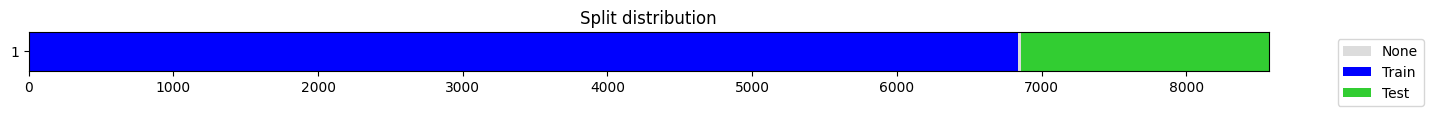


数据集划分:
  训练集样本数: 6837
  测试集样本数: 1709
[Pipeline] ............ (step 1 of 1) Processing scaler, total=   0.0s
tsai/data directory already exists.
Pipeline saved as tsai/data/exp_pipe.pkl


In [23]:
# ========== 5. 数据标准化 ==========
fcst_history = 168
fcst_horizon = 24
valid_size = 0.1
test_size = 0.2

# 先生成splits以获取训练集索引
splits = get_forecasting_splits(
    df,
    fcst_history=fcst_history,
    fcst_horizon=fcst_horizon,
    datetime_col=datetime_col,

    test_size=test_size
)

train_split = splits[0]
print(f"\n数据集划分:")
print(f"  训练集样本数: {len(train_split)}")
# print(f"  验证集样本数: {len(splits[1])}")
print(f"  测试集样本数: {len(splits[1])}")

# 标准化
columns_for_exp_pipe = df.columns[1:]
exp_pipe = sklearn.pipeline.Pipeline([
    ('scaler', TSStandardScaler(columns=columns_for_exp_pipe)),
], verbose=True)

df_scaled = exp_pipe.fit_transform(df, scaler__idxs=train_split)

# 保存标准化管道
save_object(exp_pipe, 'tsai/data/exp_pipe.pkl')

# 准备时间序列数据

在tsai中创建时间预测分割非常简单。你可以使用一个名为get_forecasting_splits的函数

为了获取这些输入和输出，我们将使用一个名为prepare_forecasting_data的函数，该函数沿数据框应用滑动窗口

In [24]:
x_vars = [col for col in df.columns if col != datetime_col]

# 为y_vars只保留center_station_id对应的列
center_vars = [col for col in df.columns if col.endswith(f"_{center_station_id}")]

print(f"\n输入变量数量 (多个站点): {len(x_vars)}")
print(f"输出变量数量 (中心站点{center_station_id}): {len(center_vars)}")
print(f"输出变量列: {center_vars}")

# 准备X: 使用所有站点的所有变量
X, _ = prepare_forecasting_data(
    df,
    fcst_history=fcst_history,
    fcst_horizon=fcst_horizon,
    x_vars=x_vars,
    y_vars=x_vars
)

# 准备y: 只使用center_station_id的变量
_, y = prepare_forecasting_data(
    df,
    fcst_history=fcst_history,
    fcst_horizon=fcst_horizon,
    x_vars=x_vars,
    y_vars=center_vars
)

print(f"\nX.shape: {X.shape}")
print(f"y.shape: {y.shape}")
print(f"预期X形状: [Samples, {n_vars_total}, {fcst_history}]")
print(f"预期y形状: [Samples, {feat_size}, {fcst_horizon}]")

# 验证维度
assert X.shape[1] == n_vars_total, f"X的通道数错误! 期望{n_vars_total}, 实际{X.shape[1]}"
assert X.shape[2] == fcst_history, f"X的时间步数错误! 期望{fcst_history}, 实际{X.shape[2]}"
assert y.shape[1] == feat_size, f"y的通道数错误! 期望{feat_size}, 实际{y.shape[1]}"
assert y.shape[2] == fcst_horizon, f"y的时间步数错误! 期望{fcst_horizon}, 实际{y.shape[2]}"

print("\n✓ 数据维度验证通过!")

np.savez('tsai/data/X.npz', X)
np.savez('tsai/data/y.npz', y)


输入变量数量 (多个站点): 144
输出变量数量 (中心站点9022): 12
输出变量列: ['PM25_Concentration_9022', 'PM10_Concentration_9022', 'NO2_Concentration_9022', 'CO_Concentration_9022', 'O3_Concentration_9022', 'SO2_Concentration_9022', 'weather_9022', 'temperature_9022', 'pressure_9022', 'humidity_9022', 'wind_speed_9022', 'wind_direction_9022']

X.shape: (8569, 144, 168)
y.shape: (8569, 12, 24)
预期X形状: [Samples, 144, 168]
预期y形状: [Samples, 12, 24]

✓ 数据维度验证通过!


# 构建并训练模型 🏋️‍♂️ 倒入模型与训练评估函数

现在我们将实例化预测器。在tsai中有一个名为TSForecaster的类。

## ST-PatchTST

In [25]:
from ST_PatchTST_model import ST_PatchTST, train_st_patchtst, evaluate_st_patchtst

## CT-PatchTST

In [ ]:
from CT_PatchTST_model import CT_PatchTST, train_ct_patchtst, evaluate_ct_patchtst

In [46]:
from CT_PatchTST_fixed import CT_PatchTST_Final, train_ct_patchtst_final

# 训练模型🏃🏿‍♂️

In [ ]:
# 加载保存的参数
params = np.load('tsai/data/model_params.npz')
num_stations = int(params['num_stations'])
feat_size = int(params['feat_size'])
n_vars_total = int(params['n_vars_total'])
fcst_history = int(params['fcst_history'])
fcst_horizon = int(params['fcst_horizon'])
    

# 模型配置
arch_config = {
    'num_stations': num_stations,
    'feat_size': feat_size,
    'arch_config': {
        'n_layers': 3,
        'n_heads': 4,
        'd_model': 128,
        'd_ff': 512,
        'dropout': 0.2
    }
}

# 实例化TSForecaster
learn = TSForecaster(
    X, y,
    splits=splits[0], # 只传入训练集索引
    batch_size=16,
    path="tsai/models",
    pipelines=[preproc_pipe, exp_pipe],
    arch=ST_PatchTST,
    arch_config=arch_config,
    metrics=[mse, mae],
    cbs=[ShowGraph()]
)

print("✓ TSForecaster实例化成功")

✓ TSForecaster实例化成功


✓ 最优学习率: 0.0002290867705596611


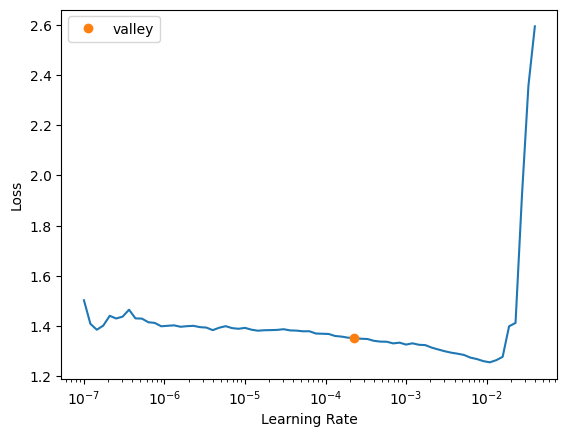

In [38]:
# 查找学习率
lr_max = learn.lr_find().valley
print(f"✓ 最优学习率: {lr_max}")

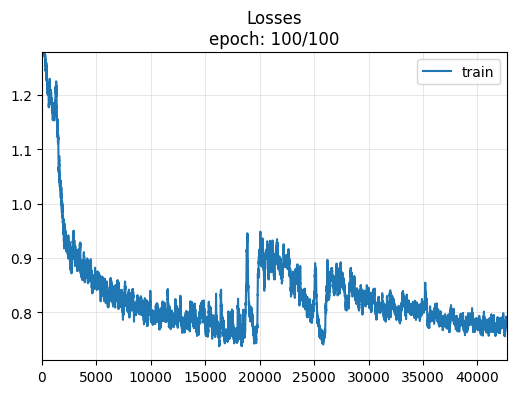

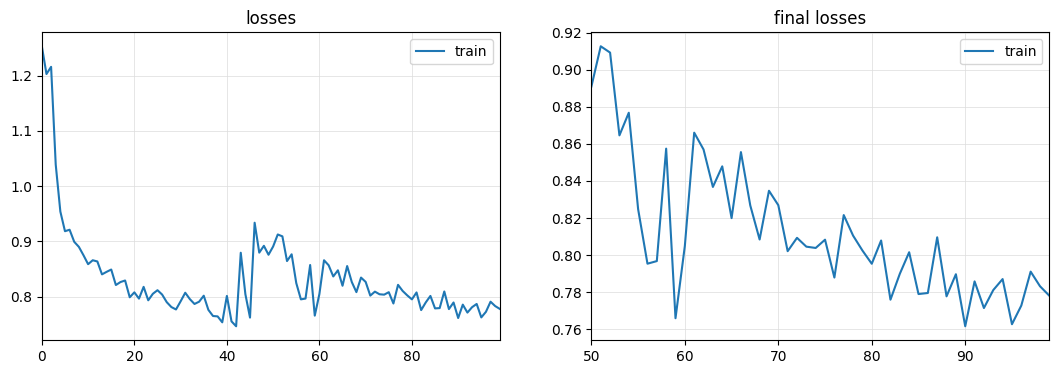

✓ 模型训练完成并已导出


In [39]:
# 训练模型
n_epochs = 100
lr = lr_max
learn.fit_one_cycle(n_epochs, lr_max=lr)

# 导出模型
learn.export('st_patchTST.pt')
print("✓ 模型训练完成并已导出")

In [ ]:
# train_st_patchtst(X, y, splits, preproc_pipe, exp_pipe)

# 评估模型 🕵️‍♀️

## 评估模型

In [45]:
learn = load_learner('tsai/models/patchTST.pt')
from sklearn.metrics import mean_squared_error, mean_absolute_error

results_df = pd.DataFrame(columns=["mse", "mae"])

# # 验证集评估
# print("\n验证集评估...")
# scaled_preds, *_ = learn.get_X_preds(X[splits[1]])
# scaled_preds = to_np(scaled_preds)
# print(f"验证集预测形状: {scaled_preds.shape}")

# scaled_y_true = y[splits[1]]
# results_df.loc["valid", "mse"] = mean_squared_error(scaled_y_true.flatten(), scaled_preds.flatten())
# results_df.loc["valid", "mae"] = mean_absolute_error(scaled_y_true.flatten(), scaled_preds.flatten())

# 测试集评估
print("\n测试集评估...")
y_test_preds, *_ = learn.get_X_preds(X[splits[1]])
y_test_preds = to_np(y_test_preds)
print(f"测试集预测形状: {y_test_preds.shape}")

y_test = y[splits[1]]
results_df.loc["test", "mse"] = mean_squared_error(y_test.flatten(), y_test_preds.flatten())
results_df.loc["test", "mae"] = mean_absolute_error(y_test.flatten(), y_test_preds.flatten())

print("\n评估结果:")
print(results_df)


测试集评估...


测试集预测形状: (1709, 12, 24)

评估结果:
           mse      mae
test  0.761625  0.67055


# 验证集

首先，我们将验证预测结果是否与训练期间获得的结果相符。但这一步并非必需，你可以选择跳过。

In [18]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
learn = load_learner('tsai/models/patchTST.pt')
scaled_preds, *_ = learn.get_X_preds(X[splits[1]])
scaled_preds = to_np(scaled_preds)
print(f"scaled_preds.shape: {scaled_preds.shape}")

scaled_y_true = y[splits[1]]
results_df = pd.DataFrame(columns=["mse", "mae"]) # 创建空的 dataframe
results_df.loc["valid", "mse"] = mean_squared_error(scaled_y_true.flatten(), scaled_preds.flatten())
results_df.loc["valid", "mae"] = mean_absolute_error(scaled_y_true.flatten(), scaled_preds.flatten())
results_df

scaled_preds.shape: (852, 12, 24)


,mse,mae
valid,1.862946,1.032144


# 测试集

因此，我们现在将使用测试集来评估性能（这也是论文中公布的结果）。

⚠️ 由于过程的随机性，你可能会发现一些差异。除此之外，原作者使用的测试数据加载器会丢弃不完整的最后一个批次，这意味着并非所有样本都被用于性能评估。而在tsai中，我们使用了所有样本。

In [19]:
learn = load_learner('tsai/models/patchTST.pt')
y_test_preds, *_ = learn.get_X_preds(X[splits[2]])
y_test_preds = to_np(y_test_preds)
print(f"y_test_preds.shape: {y_test_preds.shape}")

y_test = y[splits[2]]
# results_df = pd.DataFrame(columns=["mse", "mae"])
results_df.loc["test", "mse"] = mean_squared_error(y_test.flatten(), y_test_preds.flatten())
results_df.loc["test", "mae"] = mean_absolute_error(y_test.flatten(), y_test_preds.flatten())
results_df

y_test_preds.shape: (1705, 12, 24)


,mse,mae
valid,1.862946,1.032144
test,0.867734,0.711618


### 可视化预测

提取目标站点特征数据函数

In [42]:
def extract_center_station_X(X, x_vars, center_station_id):
    idx = [
        i for i, col in enumerate(x_vars)
        if col.endswith(f"_{center_station_id}")
    ]
    return X[:, idx, :]

可视化预测

X_test.shape: (1709, 144, 168), X_test_center.shape: (1709, 12, 168), y_test.shape: (1709, 12, 24), y_test_preds.shape: (1709, 12, 24)


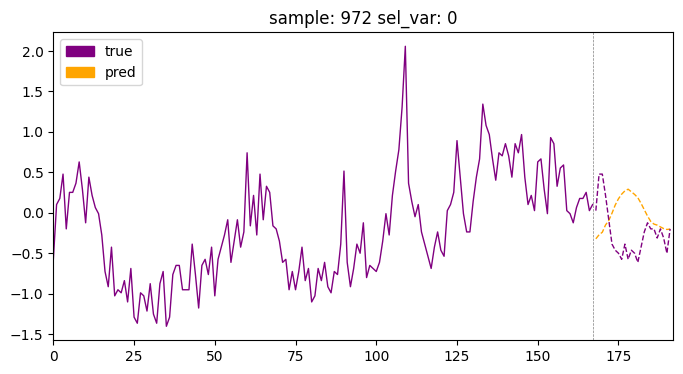

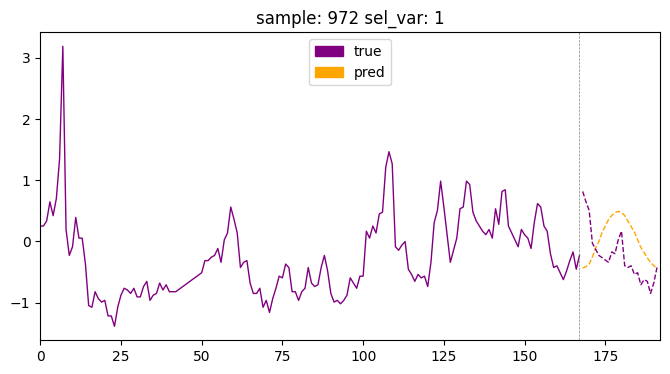

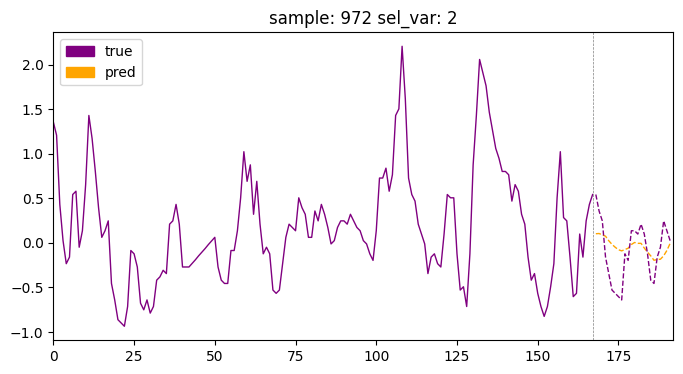

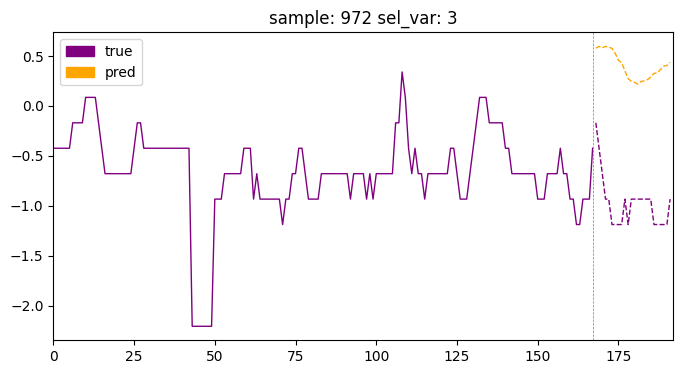

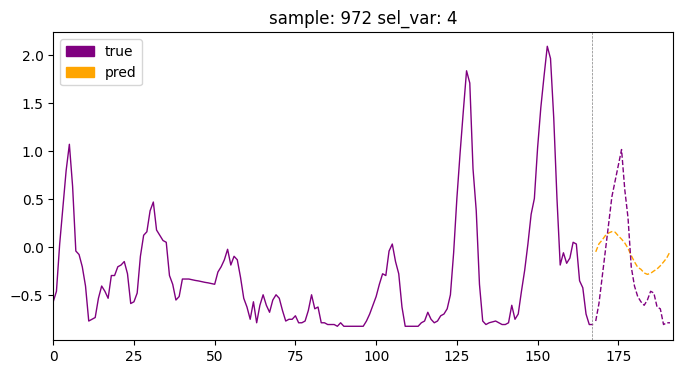

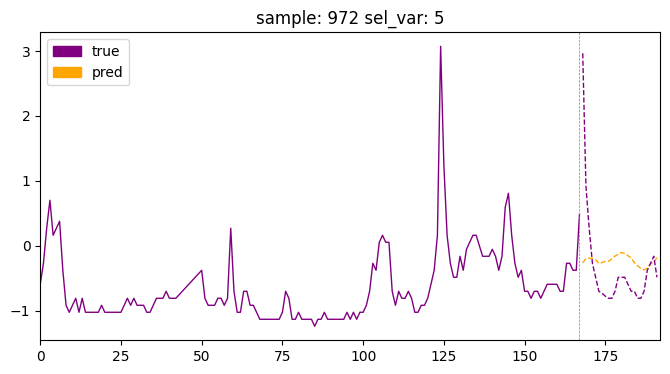

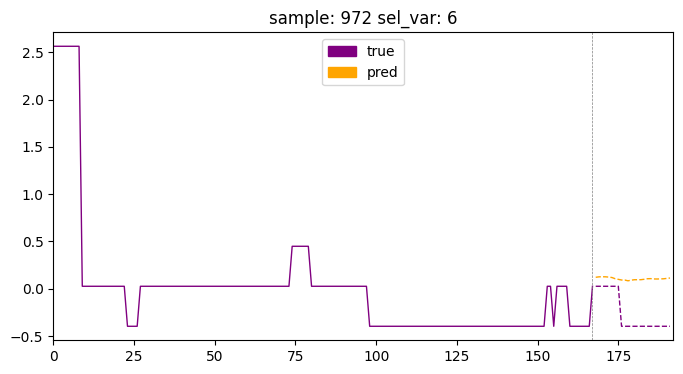

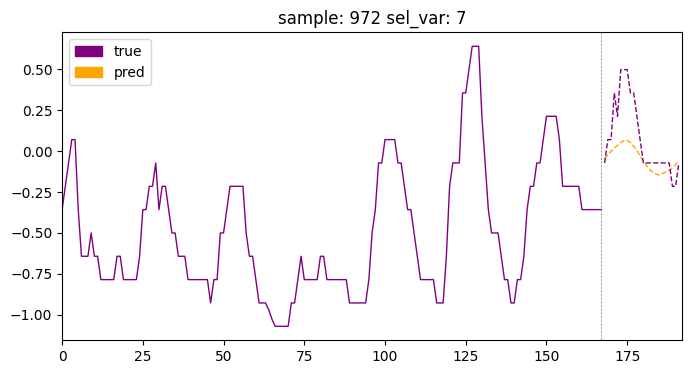

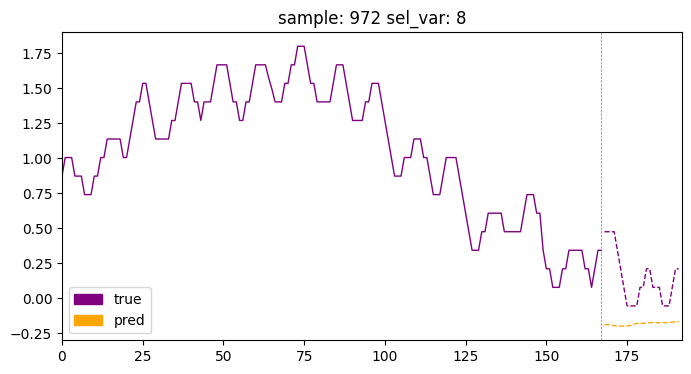

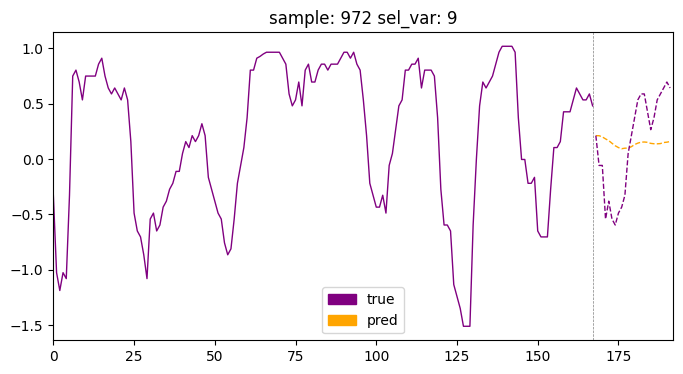

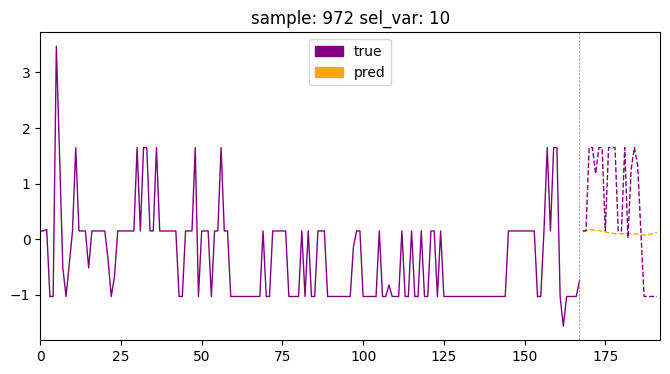

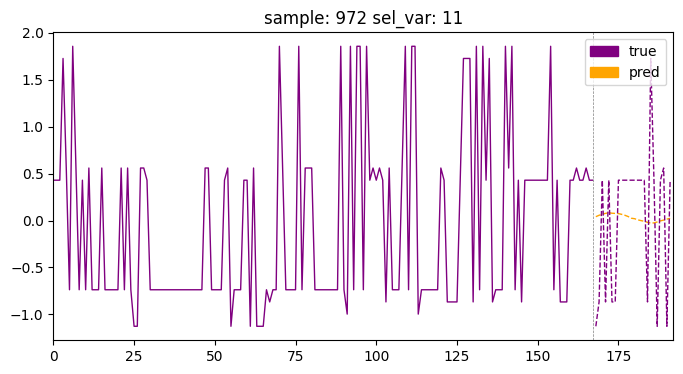

In [44]:
X_test = X[splits[1]]
y_test = y[splits[1]]

X_test_center = extract_center_station_X(X_test, x_vars, center_station_id)
print(f"X_test.shape: {X_test.shape}, X_test_center.shape: {X_test_center.shape}, y_test.shape: {y_test.shape}, y_test_preds.shape: {y_test_preds.shape}")

plot_forecast(X_test_center, y_test, y_test_preds, sel_vars=True)